In [5]:
!pip install imbalanced-learn optuna --quiet

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda

Total images : 133
Distribusi   : {0: 67, 1: 66}

Split → Train:79  Val:27  Test:27

BASELINE — EfficientNet-B0
  Ep   1/50  Loss:0.7225  Tr:48.1%  Val:44.4%
  Ep  10/50  Loss:0.6056  Tr:70.9%  Val:51.9%
  Ep  20/50  Loss:0.6180  Tr:67.1%  Val:59.3%
  Early stopping at epoch 25

  EfficientNet-B0 → Test:48.15%  TTA:59.26%

CELL A — OPTIMASI DATA & KOMPARASI ARSITEKTUR

[A1] Feature-Space SMOTE
  CNN-Feat + SMOTE + RF → Test Accuracy: 59.26%

[A3] Komparasi Multi-Arsitektur

  ── MobileNetV3-S ──
    MobileNetV3-S: 2,050 trainable params
    Ep  1/30  L:0.752  Tr:38.0%  Val:37.0%
    Ep 10/30  L:0.640  Tr:62.0%  Val:44.4%
    Ep 20/30  L:0.617  Tr:67.1%  Val:55.6%
    Ep 30/30  L:0.688  Tr:51.9%  Val:59.3%
    → Test:62.96%  TTA:59.26%

  ── ResNet50 ──
    ResNet50: 4,098 trainable params
    Ep  1/30  L:0.706  Tr:53.2%  Val:63.0%
    Ep 10/30  

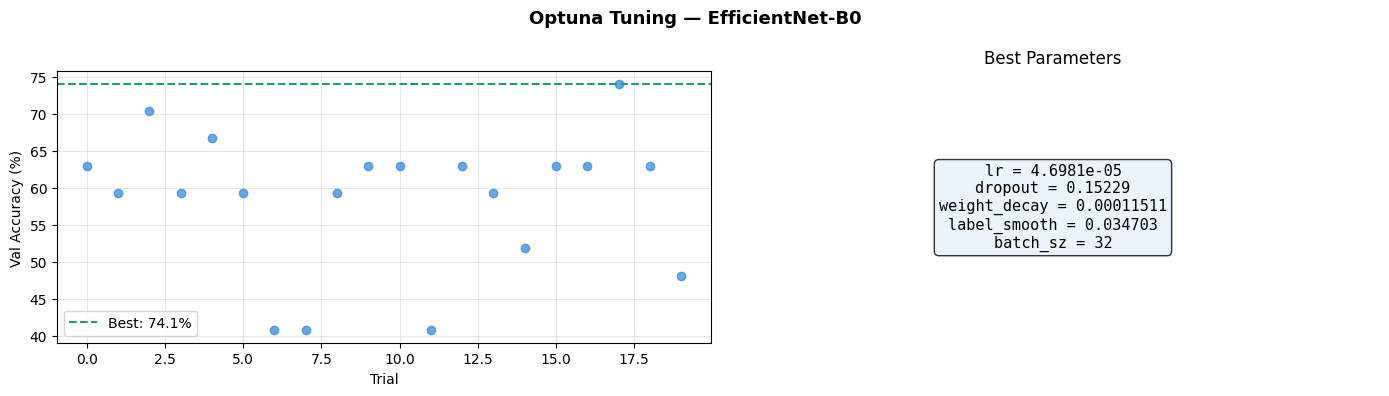


  Retraining dengan best hyperparams (full epochs)...
  Ep   1/50  Loss:0.7133  Tr:50.6%  Val:48.1%
  Ep  10/50  Loss:0.7103  Tr:53.2%  Val:33.3%
  Ep  20/50  Loss:0.7121  Tr:46.8%  Val:33.3%
  Ep  30/50  Loss:0.6968  Tr:55.7%  Val:33.3%
  Ep  40/50  Loss:0.6837  Tr:59.5%  Val:33.3%
  Ep  50/50  Loss:0.7001  Tr:51.9%  Val:33.3%

  EffNet-B0 (Tuned) → Test:55.56%  TTA:48.15%

CELL C — EVALUASI LENGKAP & VISUALISASI

  Model                        Acc     Prec      Rec       F1
──────────────────────────────────────────────────────────────────
  EfficientNet-B0           59.26%   63.21%   60.16%   57.14%
  MobileNetV3-S             59.26%   59.41%   58.79%   58.35% ←
  ResNet50                  48.15%   48.91%   49.45%   41.67%
  EfficientNet-B1           55.56%   56.47%   56.04%   55.00%
  EffNet-B0 (Tuned)         48.15%   48.68%   48.90%   46.31%

  Best (F1-macro): MobileNetV3-S

  Classification Report — MobileNetV3-S:

                      precision    recall  f1-score   support


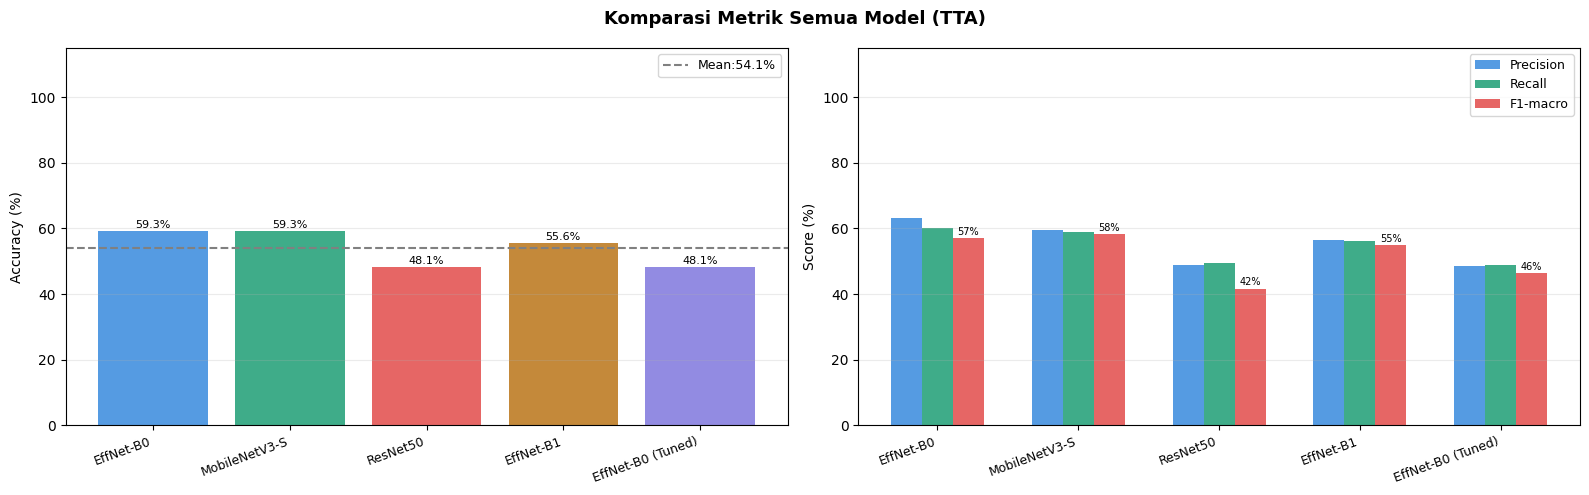

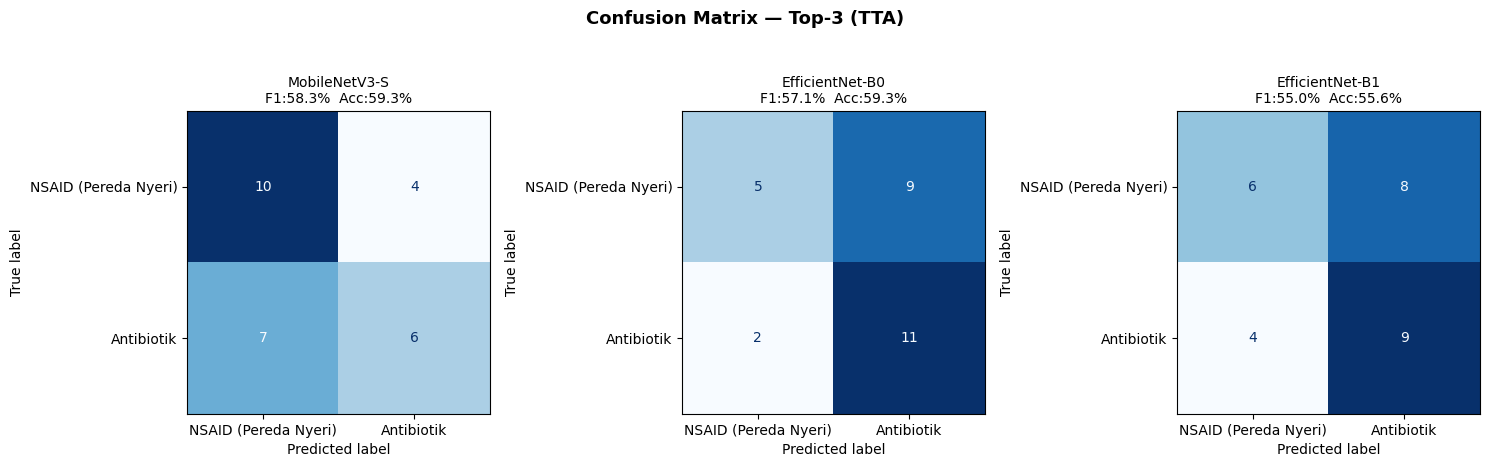

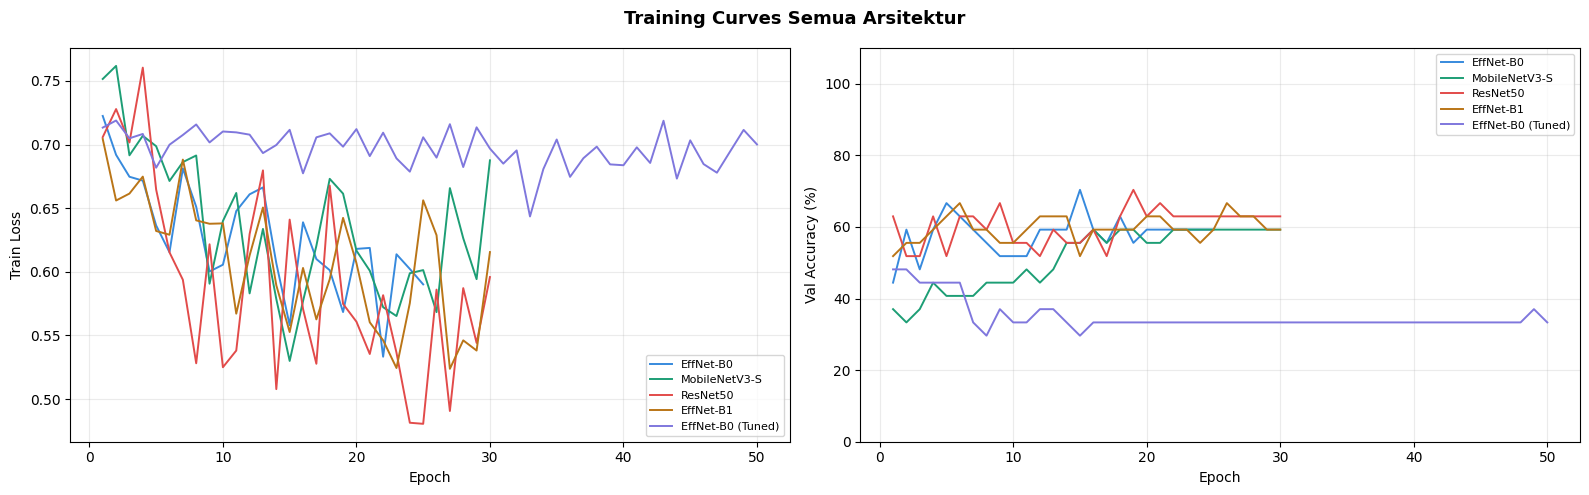

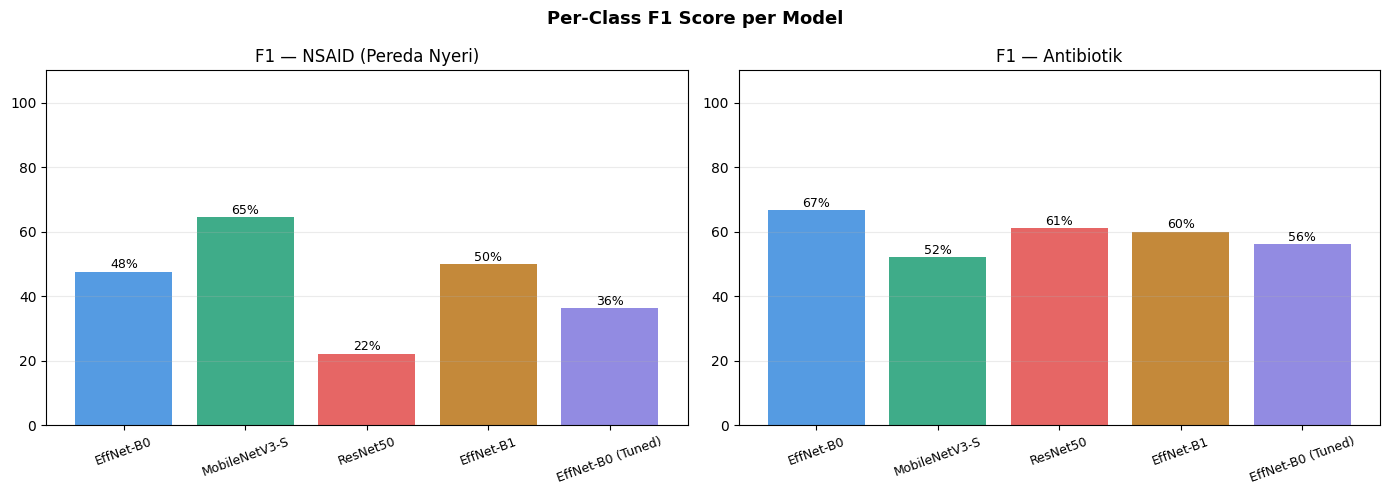

  ✓ Plot tersimpan: metric_comparison, confusion_matrix_top3, training_curves_all, perclass_f1


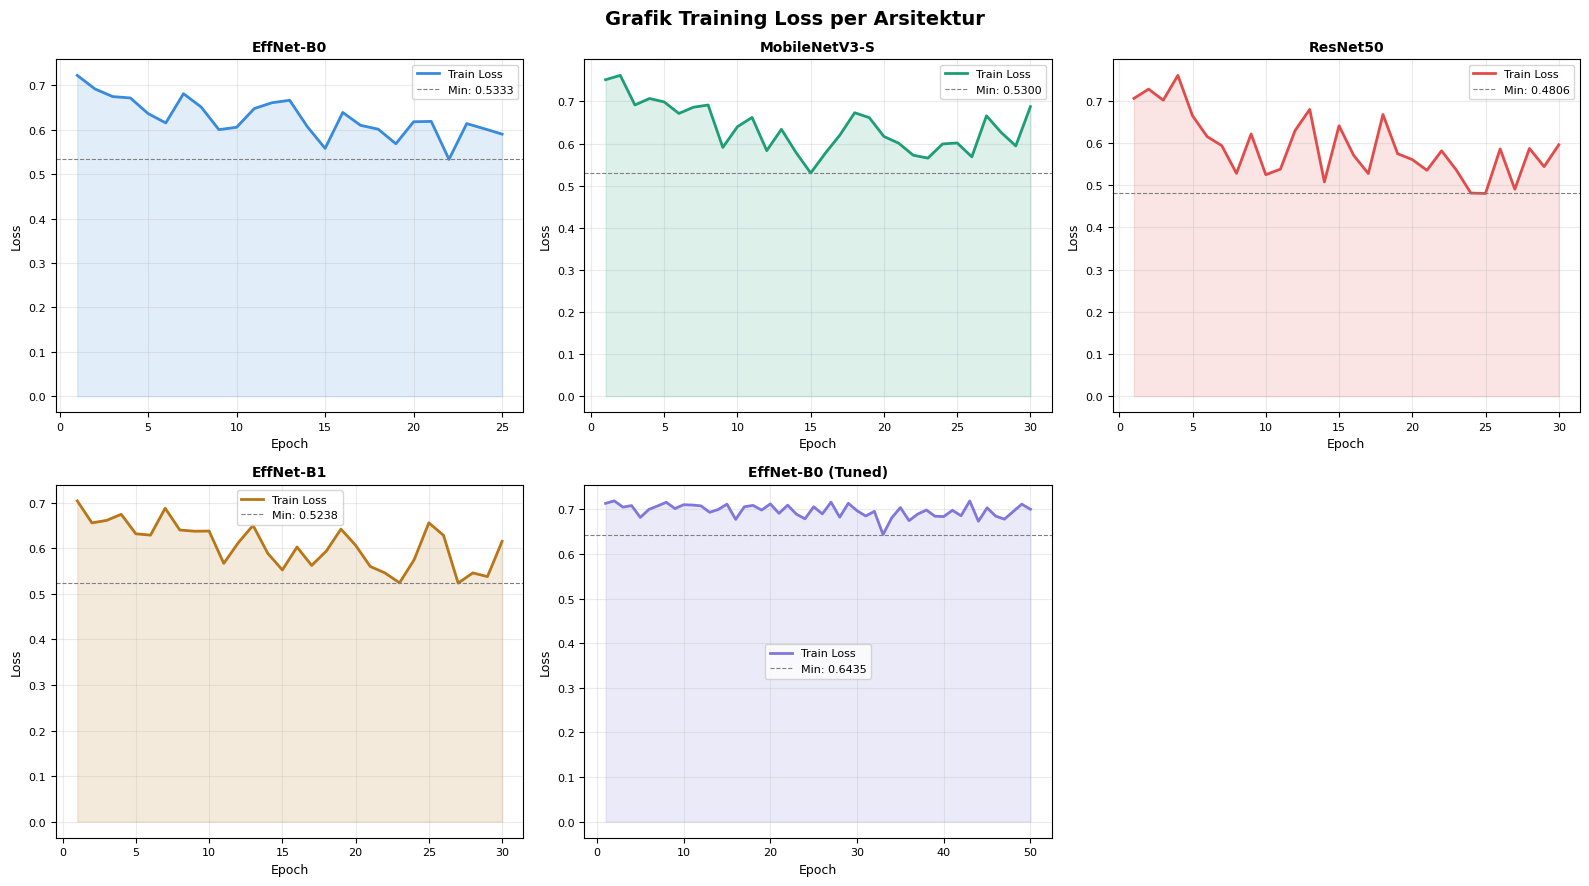

  ✓ Plot tersimpan: grafik_loss.png

CELL D — INTERPRETASI MODEL (GRAD-CAM)

  Model    : EfficientNet-B0
  TTA Acc  : 59.26%


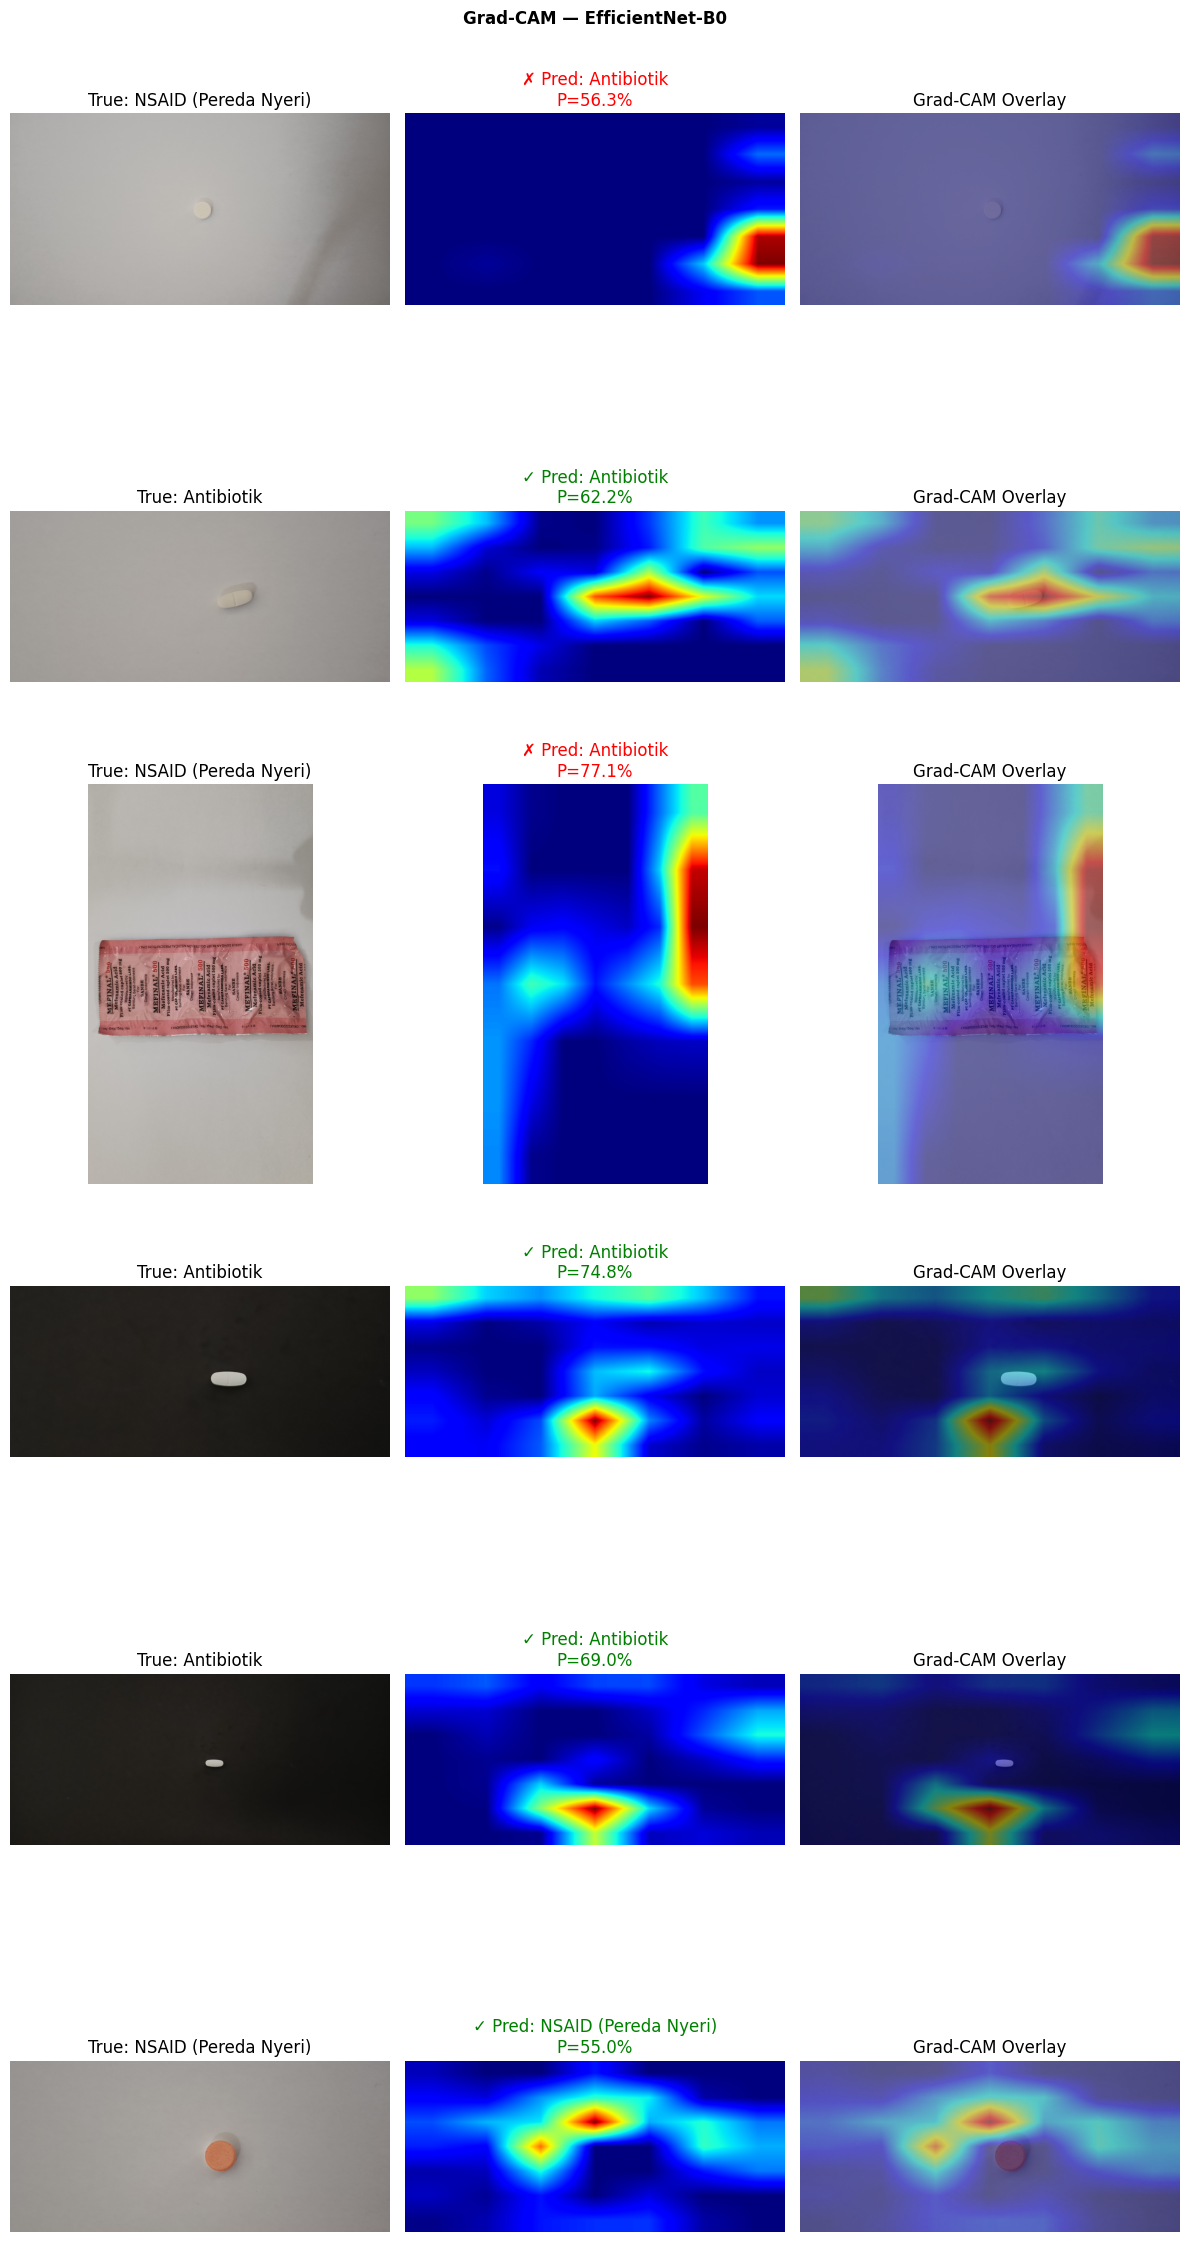

  ✓ gradcam_visualization.png tersimpan

CELL E — SIMPAN MODEL TERBAIK

  ✅ Model tersimpan!
  Arsitektur  : MobileNetV3-S
  TTA Accuracy: 59.26%
  F1-macro    : 58.35%
  Lokasi      : /content/drive/MyDrive/DatasetLASA/saved_model
  Files       : MobileNetV3_S_checkpoint.pth
                MobileNetV3_S_state_dict.pth


In [6]:
"""
=============================================================================
LASA Pill Classifier  –  Full Deep Learning Pipeline (Cell A → E)
Klasifikasi: NSAID vs Antibiotik
Metodologi : Multi-Arch Comparison + Optuna Tuning + Grad-CAM + Save
=============================================================================
Dependensi:
    pip install torch torchvision albumentations imbalanced-learn optuna --quiet
"""

# ─────────────────────────────────────────────────────────────────────────────
# 0.  IMPORTS & KONFIGURASI
# ─────────────────────────────────────────────────────────────────────────────
import copy
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import optuna
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import albumentations as A
from albumentations.pytorch import ToTensorV2
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    confusion_matrix, precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import models

# Mount Google Drive (Colab)
from google.colab import drive
drive.mount("/content/drive")

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Konfigurasi ──────────────────────────────────────────────────────────────
DATASET_ROOT = Path("/content/drive/MyDrive/DatasetLASA")
DIR_LABEL_MAP = {
    "pereda_nyeri":         0,
    "pereda_nyeri_bungkus": 0,
    "antibiotik":           1,
    "antibiotik_Bungkus":   1,
}
CLASS_NAMES   = ["NSAID (Pereda Nyeri)", "Antibiotik"]
SAVE_DIR      = Path("/content/drive/MyDrive/DatasetLASA/saved_model")

SEED          = 42
IMG_SIZE      = 224
BATCH_SIZE    = 16
NUM_EPOCHS    = 50
NUM_WORKERS   = 2
PIN_MEMORY    = True
LR_HEAD       = 1e-3
WEIGHT_DECAY  = 1e-4
TTA_N         = 5          # jumlah augmentasi TTA
COMP_EPOCHS   = 30         # epoch komparasi arsitektur (Cell A)
OPTUNA_EPOCHS = 15         # epoch per trial Optuna (Cell B)
N_TRIALS      = 20         # jumlah trial Optuna

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")


# ─────────────────────────────────────────────────────────────────────────────
# 1.  DATA PIPELINE
# ─────────────────────────────────────────────────────────────────────────────
train_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=30, p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])


class PillDataset(Dataset):
    def __init__(self, images, labels, transform):
        self.images, self.labels, self.transform = images, labels, transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.transform(image=self.images[idx])["image"]
        return img, self.labels[idx]


# ── Load & Split (60 / 20 / 20) ──────────────────────────────────────────────
all_imgs, all_labels = [], []
for subdir, label in DIR_LABEL_MAP.items():
    folder = DATASET_ROOT / subdir
    if not folder.exists():
        continue
    for f in folder.iterdir():
        if f.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue
        img = cv2.imread(str(f))
        if img is None:
            continue
        all_imgs.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        all_labels.append(label)

all_labels = np.array(all_labels)
print(f"Total images : {len(all_imgs)}")
print(f"Distribusi   : {dict(enumerate(np.bincount(all_labels).tolist()))}\n")

X_tr_p, X_tmp, y_tr, y_tmp = train_test_split(
    all_imgs, all_labels, test_size=0.40, stratify=all_labels, random_state=SEED
)
X_vl_p, X_te_p, y_vl, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED
)
print(f"Split → Train:{len(y_tr)}  Val:{len(y_vl)}  Test:{len(y_te)}\n")

# Class weight untuk loss & sampler
cw_arr = (1.0 / np.bincount(y_tr)).astype(np.float32)
cw_arr = cw_arr / cw_arr.sum() * len(np.unique(y_tr))


# ─────────────────────────────────────────────────────────────────────────────
# 2.  UTILITY FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────
def make_criterion(cw):
    return nn.CrossEntropyLoss(weight=torch.tensor(cw, dtype=torch.float).to(device))


def make_weighted_loader(imgs, lbls, transform, batch_size=BATCH_SIZE):
    cw  = 1.0 / np.bincount(lbls).astype(float)
    sw  = torch.tensor([cw[l] for l in lbls], dtype=torch.float)
    smp = WeightedRandomSampler(sw, num_samples=len(lbls), replacement=True)
    return DataLoader(
        PillDataset(imgs, lbls, transform),
        batch_size=batch_size, sampler=smp,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == lbls).sum().item()
        total      += lbls.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate_loader(model, loader):
    model.eval()
    preds, labels = [], []
    for imgs, lbls in loader:
        out = model(imgs.to(device))
        preds.extend(out.argmax(1).cpu().numpy())
        labels.extend(lbls.numpy())
    preds, labels = np.array(preds), np.array(labels)
    return accuracy_score(labels, preds), preds, labels


def predict_tta(model, images, n=TTA_N):
    """Test-Time Augmentation: rata-rata n prediksi dengan train_aug."""
    model.eval()
    all_probs = []
    for _ in range(n):
        probs = []
        with torch.no_grad():
            for img in images:
                t = train_aug(image=img)["image"].unsqueeze(0).to(device)
                p = F.softmax(model(t), dim=1).cpu().numpy()[0]
                probs.append(p)
        all_probs.append(np.array(probs))
    return np.mean(all_probs, axis=0).argmax(axis=1)


def compute_metrics(y_true, y_pred):
    acc              = accuracy_score(y_true, y_pred)
    p, r, f1, _     = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=[0, 1], zero_division=0)
    pm, rm, f1m, _  = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    return {
        "acc": acc, "f1_mac": f1m, "prec_mac": pm, "rec_mac": rm,
        "prec": list(p), "rec": list(r), "f1": list(f1),
    }


# ─────────────────────────────────────────────────────────────────────────────
# 3.  BASELINE: EfficientNet-B0 (model awal sebelum Cell A)
# ─────────────────────────────────────────────────────────────────────────────
def build_efficientnet_b0(dropout=0.4):
    net = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    for p in net.features.parameters():
        p.requires_grad = False
    in_f = net.classifier[1].in_features
    net.classifier = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(in_f, 2))
    return net.to(device)


print("=" * 62)
print("BASELINE — EfficientNet-B0")
print("=" * 62)

final_model = build_efficientnet_b0()
criterion_b = make_criterion(cw_arr)
optimizer_b = optim.Adam(
    final_model.classifier.parameters(), lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
scheduler_b = optim.lr_scheduler.CosineAnnealingLR(optimizer_b, T_max=NUM_EPOCHS)

tr_dl = make_weighted_loader(X_tr_p, y_tr, train_aug)
vl_dl = DataLoader(PillDataset(X_vl_p, y_vl, val_aug), batch_size=BATCH_SIZE, shuffle=False)
te_dl = DataLoader(PillDataset(X_te_p, y_te, val_aug), batch_size=BATCH_SIZE, shuffle=False)

history = {"train_loss": [], "train_acc": [], "val_acc": []}
best_val, best_wts, no_improve = 0.0, None, 0
patience = 10

for ep in range(1, NUM_EPOCHS + 1):
    tl, ta   = train_one_epoch(final_model, tr_dl, criterion_b, optimizer_b)
    va, _, _ = evaluate_loader(final_model, vl_dl)
    scheduler_b.step()
    history["train_loss"].append(tl)
    history["train_acc"].append(ta)
    history["val_acc"].append(va)
    if va > best_val:
        best_val, best_wts, no_improve = va, copy.deepcopy(final_model.state_dict()), 0
    else:
        no_improve += 1
    if ep % 10 == 0 or ep == 1:
        print(f"  Ep {ep:3d}/{NUM_EPOCHS}  Loss:{tl:.4f}  Tr:{ta*100:.1f}%  Val:{va*100:.1f}%")
    if no_improve >= patience:
        print(f"  Early stopping at epoch {ep}")
        break

final_model.load_state_dict(best_wts)
test_acc, _, _ = evaluate_loader(final_model, te_dl)
tta_preds      = predict_tta(final_model, X_te_p)
tta_acc        = accuracy_score(y_te, tta_preds)
print(f"\n  EfficientNet-B0 → Test:{test_acc*100:.2f}%  TTA:{tta_acc*100:.2f}%\n")


# ─────────────────────────────────────────────────────────────────────────────
# CELL A  —  OPTIMASI DATA & KOMPARASI ARSITEKTUR
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 62)
print("CELL A — OPTIMASI DATA & KOMPARASI ARSITEKTUR")
print("=" * 62)

# A1. Feature-Space SMOTE (CNN fitur → SMOTE → Random Forest)
@torch.no_grad()
def extract_cnn_features(model, images):
    """Ekstrak fitur 1280-dim dari backbone EfficientNet-B0."""
    model.eval()
    feats = []
    for img in images:
        t = val_aug(image=img)["image"].unsqueeze(0).to(device)
        f = model.features(t)
        f = model.avgpool(f)
        feats.append(torch.flatten(f, 1).cpu().numpy())
    return np.vstack(feats)


print("\n[A1] Feature-Space SMOTE")
X_feat_tr = extract_cnn_features(final_model, X_tr_p)
X_feat_te = extract_cnn_features(final_model, X_te_p)

k_nn     = max(1, int(np.bincount(y_tr).min()) - 1)
X_sm, y_sm = SMOTE(random_state=SEED, k_neighbors=k_nn).fit_resample(X_feat_tr, y_tr)
clf_smote  = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=SEED)
clf_smote.fit(X_sm, y_sm)
smote_acc  = accuracy_score(y_te, clf_smote.predict(X_feat_te))
print(f"  CNN-Feat + SMOTE + RF → Test Accuracy: {smote_acc*100:.2f}%")

# A2. Builder functions (frozen backbone)
def build_mobilenet_v3():
    net = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    for p in net.parameters(): p.requires_grad = False
    in_f = net.classifier[3].in_features
    net.classifier[3] = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_f, 2))
    return net.to(device)

def build_resnet50():
    net = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    for p in net.parameters(): p.requires_grad = False
    in_f = net.fc.in_features
    net.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_f, 2))
    return net.to(device)

def build_efficientnet_b1():
    net = models.efficientnet_b1(weights=models.EfficientNet_B1_Weights.IMAGENET1K_V1)
    for p in net.parameters(): p.requires_grad = False
    in_f = net.classifier[1].in_features
    net.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_f, 2))
    return net.to(device)

# A3. Generic training function
def train_arch(model_fn, name, epochs=COMP_EPOCHS):
    net = model_fn()
    tp  = [p for p in net.parameters() if p.requires_grad]
    print(f"    {name}: {sum(p.numel() for p in tp):,} trainable params")
    opt = optim.Adam(tp, lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crt = make_criterion(cw_arr)

    tr_dl_a = make_weighted_loader(X_tr_p, y_tr, train_aug)
    vl_dl_a = DataLoader(PillDataset(X_vl_p, y_vl, val_aug), batch_size=BATCH_SIZE, shuffle=False)
    te_dl_a = DataLoader(PillDataset(X_te_p, y_te, val_aug), batch_size=BATCH_SIZE, shuffle=False)

    h = {"train_loss": [], "train_acc": [], "val_acc": []}
    best_v, best_st = 0.0, None

    for ep in range(1, epochs + 1):
        tl, ta   = train_one_epoch(net, tr_dl_a, crt, opt)
        va, _, _ = evaluate_loader(net, vl_dl_a)
        sch.step()
        h["train_loss"].append(tl); h["train_acc"].append(ta); h["val_acc"].append(va)
        if va > best_v:
            best_v, best_st = va, copy.deepcopy(net.state_dict())
        if ep % 10 == 0 or ep == 1:
            print(f"    Ep {ep:2d}/{epochs}  L:{tl:.3f}  Tr:{ta*100:.1f}%  Val:{va*100:.1f}%")

    net.load_state_dict(best_st)
    tacc, _, _ = evaluate_loader(net, te_dl_a)
    tta_p      = predict_tta(net, X_te_p)
    tta_a      = accuracy_score(y_te, tta_p)
    print(f"    → Test:{tacc*100:.2f}%  TTA:{tta_a*100:.2f}%")
    return net, h, tacc, tta_a, tta_p

# A4. Inisialisasi arch_results dengan baseline B0
arch_results = {
    "EfficientNet-B0": {
        "model": final_model, "history": history,
        "test_acc": test_acc, "tta_acc": tta_acc, "tta_preds": tta_preds,
    }
}

print("\n[A3] Komparasi Multi-Arsitektur")
for _name, _fn in [
    ("MobileNetV3-S",   build_mobilenet_v3),
    ("ResNet50",        build_resnet50),
    ("EfficientNet-B1", build_efficientnet_b1),
]:
    print(f"\n  ── {_name} ──")
    _m, _h, _ta, _tta, _ttp = train_arch(_fn, _name)
    arch_results[_name] = {
        "model": _m, "history": _h,
        "test_acc": _ta, "tta_acc": _tta, "tta_preds": _ttp,
    }
    if torch.cuda.is_available(): torch.cuda.empty_cache()

# A5. Tabel ringkasan
print("\n" + "=" * 58)
_best_tta = max(r["tta_acc"] for r in arch_results.values())
for _n, _r in arch_results.items():
    flag = "  ← best" if _r["tta_acc"] == _best_tta else ""
    print(f"  {_n:<22}  Test:{_r['test_acc']*100:>6.2f}%  TTA:{_r['tta_acc']*100:>6.2f}%{flag}")
print(f"\n  SMOTE+RF baseline: {smote_acc*100:.2f}%")


# ─────────────────────────────────────────────────────────────────────────────
# CELL B  —  HYPERPARAMETER TUNING (OPTUNA)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 62)
print("CELL B — HYPERPARAMETER TUNING (OPTUNA)")
print("=" * 62)

def objective(trial):
    lr  = trial.suggest_float("lr",           1e-5, 1e-2, log=True)
    do  = trial.suggest_float("dropout",      0.1, 0.7)
    wd  = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    ls  = trial.suggest_float("label_smooth", 0.0, 0.25)
    bs  = trial.suggest_categorical("batch_sz", [8, 16, 32])

    net = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    for p in net.features.parameters(): p.requires_grad = False
    in_f = net.classifier[1].in_features
    net.classifier = nn.Sequential(nn.Dropout(p=do), nn.Linear(in_f, 2))
    net = net.to(device)

    crit    = nn.CrossEntropyLoss(
        weight=torch.tensor(cw_arr, dtype=torch.float).to(device), label_smoothing=ls)
    opt_    = optim.Adam(net.classifier.parameters(), lr=lr, weight_decay=wd)
    sch_    = optim.lr_scheduler.CosineAnnealingLR(opt_, T_max=OPTUNA_EPOCHS)
    tr_dl_o = DataLoader(PillDataset(X_tr_p, y_tr, train_aug),
                         batch_size=bs, shuffle=True,
                         num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    vl_dl_o = DataLoader(PillDataset(X_vl_p, y_vl, val_aug),
                         batch_size=bs, shuffle=False)

    best_v = 0.0
    for ep in range(OPTUNA_EPOCHS):
        train_one_epoch(net, tr_dl_o, crit, opt_)
        sch_.step()
        va, _, _ = evaluate_loader(net, vl_dl_o)
        best_v = max(best_v, va)
        trial.report(va, ep)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    return best_v

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5),
)
study.optimize(objective, n_trials=N_TRIALS, timeout=720)

bp = study.best_params
print(f"\n  Best Val Acc : {study.best_value*100:.2f}%")
print("  Best Params  :")
for k, v in bp.items():
    print(f"    {k:<16}: {v:.5g}")

# Optuna: trial history plot
completed = [t for t in study.trials if t.value is not None]
fig_opt, (ax_o1, ax_o2) = plt.subplots(1, 2, figsize=(14, 4))
fig_opt.suptitle("Optuna Tuning — EfficientNet-B0", fontsize=13, fontweight="bold")
ax_o1.scatter([t.number for t in completed], [t.value*100 for t in completed],
              c="#378ADD", alpha=0.75, zorder=3)
ax_o1.axhline(study.best_value*100, color="#1D9E75", linestyle="--",
              label=f"Best: {study.best_value*100:.1f}%")
ax_o1.set_xlabel("Trial"); ax_o1.set_ylabel("Val Accuracy (%)"); ax_o1.legend(); ax_o1.grid(alpha=0.3)
param_text = "\n".join([f"{k} = {v:.5g}" for k, v in bp.items()])
ax_o2.text(0.5, 0.5, param_text, ha="center", va="center",
           fontsize=11, fontfamily="monospace", transform=ax_o2.transAxes,
           bbox=dict(boxstyle="round", facecolor="#E6F1FB", alpha=0.8))
ax_o2.set_title("Best Parameters"); ax_o2.axis("off")
plt.tight_layout()
plt.savefig("optuna_results.png", dpi=150, bbox_inches="tight")
plt.show()

# Retrain dengan best hyperparams
print("\n  Retraining dengan best hyperparams (full epochs)...")
net_tuned = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
for p in net_tuned.features.parameters(): p.requires_grad = False
in_f = net_tuned.classifier[1].in_features
net_tuned.classifier = nn.Sequential(nn.Dropout(p=bp["dropout"]), nn.Linear(in_f, 2))
net_tuned = net_tuned.to(device)

crit_t  = nn.CrossEntropyLoss(
    weight=torch.tensor(cw_arr, dtype=torch.float).to(device), label_smoothing=bp["label_smooth"])
opt_t   = optim.Adam(net_tuned.classifier.parameters(), lr=bp["lr"], weight_decay=bp["weight_decay"])
sch_t   = optim.lr_scheduler.CosineAnnealingLR(opt_t, T_max=NUM_EPOCHS)
tr_dl_t = DataLoader(PillDataset(X_tr_p, y_tr, train_aug),
                     batch_size=int(bp["batch_sz"]), shuffle=True,
                     num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

hist_t = {"train_loss": [], "train_acc": [], "val_acc": []}
best_v_t, best_st_t = 0.0, None

for ep in range(1, NUM_EPOCHS + 1):
    tl, ta   = train_one_epoch(net_tuned, tr_dl_t, crit_t, opt_t)
    va, _, _ = evaluate_loader(net_tuned, vl_dl)
    sch_t.step()
    hist_t["train_loss"].append(tl)
    hist_t["train_acc"].append(ta)
    hist_t["val_acc"].append(va)
    if va > best_v_t:
        best_v_t, best_st_t = va, copy.deepcopy(net_tuned.state_dict())
    if ep % 10 == 0 or ep == 1:
        print(f"  Ep {ep:3d}/{NUM_EPOCHS}  Loss:{tl:.4f}  Tr:{ta*100:.1f}%  Val:{va*100:.1f}%")

net_tuned.load_state_dict(best_st_t)
tacc_t, _, _ = evaluate_loader(net_tuned, te_dl)
tta_preds_t  = predict_tta(net_tuned, X_te_p)
tta_acc_t    = accuracy_score(y_te, tta_preds_t)
print(f"\n  EffNet-B0 (Tuned) → Test:{tacc_t*100:.2f}%  TTA:{tta_acc_t*100:.2f}%")

arch_results["EffNet-B0 (Tuned)"] = {
    "model": net_tuned, "history": hist_t,
    "test_acc": tacc_t, "tta_acc": tta_acc_t, "tta_preds": tta_preds_t,
}


# ─────────────────────────────────────────────────────────────────────────────
# CELL C  —  EVALUASI LENGKAP & VISUALISASI
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 62)
print("CELL C — EVALUASI LENGKAP & VISUALISASI")
print("=" * 62)

all_metrics = {n: compute_metrics(y_te, r["tta_preds"]) for n, r in arch_results.items()}

print(f"\n  {'Model':<24} {'Acc':>7}  {'Prec':>7}  {'Rec':>7}  {'F1':>7}")
print("─" * 66)
best_f1 = max(v["f1_mac"] for v in all_metrics.values())
for _n, _m in all_metrics.items():
    flag = " ←" if _m["f1_mac"] == best_f1 else ""
    print(f"  {_n:<24} {_m['acc']*100:>6.2f}%  {_m['prec_mac']*100:>6.2f}%  "
          f"{_m['rec_mac']*100:>6.2f}%  {_m['f1_mac']*100:>6.2f}%{flag}")

best_cell_c = max(all_metrics, key=lambda k: all_metrics[k]["f1_mac"])
print(f"\n  Best (F1-macro): {best_cell_c}")
print(f"\n  Classification Report — {best_cell_c}:\n")
print(classification_report(y_te, arch_results[best_cell_c]["tta_preds"],
                             target_names=CLASS_NAMES, digits=4))

_names   = list(all_metrics.keys())
_short   = [n.replace("EfficientNet", "EffNet") for n in _names]
_palette = ["#378ADD", "#1D9E75", "#E24B4A", "#BA7517", "#7F77DD"]
_x       = np.arange(len(_names))

# Fig 1: Accuracy + P/R/F1
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig1.suptitle("Komparasi Metrik Semua Model (TTA)", fontsize=13, fontweight="bold")
_accs = [all_metrics[n]["acc"]*100 for n in _names]
bars  = ax1.bar(_x, _accs, color=_palette[:len(_names)], alpha=0.85)
ax1.axhline(np.mean(_accs), color="gray", linestyle="--",
            label=f"Mean:{np.mean(_accs):.1f}%")
ax1.set_xticks(_x); ax1.set_xticklabels(_short, rotation=20, ha="right", fontsize=9)
ax1.set_ylabel("Accuracy (%)"); ax1.set_ylim(0, 115); ax1.legend(fontsize=9); ax1.grid(axis="y", alpha=0.25)
for b in bars:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+1, f"{b.get_height():.1f}%", ha="center", fontsize=8)
_w = 0.22
ax2.bar(_x-_w, [all_metrics[n]["prec_mac"]*100 for n in _names], _w, label="Precision", color="#378ADD", alpha=0.85)
ax2.bar(_x,    [all_metrics[n]["rec_mac"]*100  for n in _names], _w, label="Recall",    color="#1D9E75", alpha=0.85)
_bf = ax2.bar(_x+_w, [all_metrics[n]["f1_mac"]*100 for n in _names], _w, label="F1-macro",  color="#E24B4A", alpha=0.85)
ax2.set_xticks(_x); ax2.set_xticklabels(_short, rotation=20, ha="right", fontsize=9)
ax2.set_ylabel("Score (%)"); ax2.set_ylim(0, 115); ax2.legend(fontsize=9); ax2.grid(axis="y", alpha=0.25)
for b in _bf:
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+1, f"{b.get_height():.0f}%", ha="center", fontsize=7)
plt.tight_layout()
plt.savefig("metric_comparison.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 2: Top-3 Confusion Matrix
_top3   = sorted(all_metrics, key=lambda k: all_metrics[k]["f1_mac"], reverse=True)[:3]
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
fig2.suptitle("Confusion Matrix — Top-3 (TTA)", fontsize=13, fontweight="bold")
for ax, n in zip(axes2, _top3):
    cm = confusion_matrix(y_te, arch_results[n]["tta_preds"])
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{n}\nF1:{all_metrics[n]['f1_mac']*100:.1f}%  Acc:{all_metrics[n]['acc']*100:.1f}%", fontsize=10)
plt.tight_layout()
plt.savefig("confusion_matrix_top3.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 3: Training Curves
fig3, (ax_l, ax_v) = plt.subplots(1, 2, figsize=(16, 5))
fig3.suptitle("Training Curves Semua Arsitektur", fontsize=13, fontweight="bold")
for i, (n, r) in enumerate(arch_results.items()):
    h  = r["history"]
    ep = range(1, len(h["train_loss"]) + 1)
    c  = _palette[i % len(_palette)]
    lb = n.replace("EfficientNet", "EffNet")
    ax_l.plot(ep, h["train_loss"], label=lb, color=c, linewidth=1.4)
    ax_v.plot(ep, [v*100 for v in h["val_acc"]], label=lb, color=c, linewidth=1.4)
ax_l.set_xlabel("Epoch"); ax_l.set_ylabel("Train Loss"); ax_l.legend(fontsize=8); ax_l.grid(alpha=0.25)
ax_v.set_xlabel("Epoch"); ax_v.set_ylabel("Val Accuracy (%)"); ax_v.legend(fontsize=8)
ax_v.set_ylim(0, 110); ax_v.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("training_curves_all.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 4: Per-Class F1
fig4, axes4 = plt.subplots(1, 2, figsize=(14, 5))
fig4.suptitle("Per-Class F1 Score per Model", fontsize=13, fontweight="bold")
for ci, (ax4, cls) in enumerate(zip(axes4, CLASS_NAMES)):
    f1c  = [all_metrics[n]["f1"][ci]*100 for n in _names]
    bars = ax4.bar(_short, f1c, color=_palette[:len(_names)], alpha=0.85)
    ax4.set_title(f"F1 — {cls}"); ax4.set_ylim(0, 110); ax4.grid(axis="y", alpha=0.25)
    ax4.tick_params(axis="x", rotation=20, labelsize=9)
    for b in bars:
        ax4.text(b.get_x()+b.get_width()/2, b.get_height()+1, f"{b.get_height():.0f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("perclass_f1.png", dpi=150, bbox_inches="tight"); plt.show()
print("  ✓ Plot tersimpan: metric_comparison, confusion_matrix_top3, training_curves_all, perclass_f1")

# ── Fig 5: Grafik Loss per Arsitektur ────────────────────────────────────────
fig5, axes5 = plt.subplots(2, 3, figsize=(16, 9))
fig5.suptitle("Grafik Training Loss per Arsitektur", fontsize=14, fontweight="bold")
axes5_flat = axes5.flatten()

for i, (n, r) in enumerate(arch_results.items()):
    ax = axes5_flat[i]
    h  = r["history"]
    ep = range(1, len(h["train_loss"]) + 1)
    c  = _palette[i % len(_palette)]
    lb = n.replace("EfficientNet", "EffNet")

    ax.plot(ep, h["train_loss"], color=c, linewidth=2, label="Train Loss")
    ax.fill_between(ep, h["train_loss"], alpha=0.15, color=c)
    ax.axhline(min(h["train_loss"]), color="gray", linestyle="--", linewidth=0.8,
               label=f"Min: {min(h['train_loss']):.4f}")
    ax.set_title(lb, fontsize=10, fontweight="bold")
    ax.set_xlabel("Epoch", fontsize=9)
    ax.set_ylabel("Loss", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
    ax.tick_params(labelsize=8)

# Sembunyikan subplot kosong jika model < 6
for j in range(len(arch_results), len(axes5_flat)):
    axes5_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig("grafik_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Plot tersimpan: grafik_loss.png")


# ─────────────────────────────────────────────────────────────────────────────
# CELL D  —  GRAD-CAM & ANALISIS KOMPARATIF
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 62)
print("CELL D — INTERPRETASI MODEL (GRAD-CAM)")
print("=" * 62)


class GradCAM:
    """Grad-CAM via forward hook + tensor hook (Selvaraju et al., 2017)."""

    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        self._handle     = target_layer.register_forward_hook(self._fwd_hook)

    def _fwd_hook(self, module, inp, out):
        out.register_hook(lambda g: setattr(self, "gradients", g.detach().clone()))
        self.activations = out.detach().clone()

    @torch.enable_grad()
    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        inp    = input_tensor.detach().clone().requires_grad_(True)
        out    = self.model(inp)
        pred   = out.argmax(1).item()
        probs  = out.softmax(1).detach().cpu().numpy()[0]
        if class_idx is None: class_idx = pred
        self.model.zero_grad()
        out[0, class_idx].backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam     = (weights * self.activations).sum(dim=1).squeeze()
        cam     = torch.clamp(cam, min=0).cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, pred, probs

    def remove_hook(self):
        self._handle.remove()


best_gcam_name  = max(arch_results, key=lambda k: arch_results[k]["tta_acc"])
best_gcam_model = arch_results[best_gcam_name]["model"]
best_gcam_preds = arch_results[best_gcam_name]["tta_preds"]
print(f"\n  Model    : {best_gcam_name}")
print(f"  TTA Acc  : {arch_results[best_gcam_name]['tta_acc']*100:.2f}%")

target_layer = (best_gcam_model.layer4[-1] if "ResNet" in best_gcam_name
                else best_gcam_model.features[-1])
gcam = GradCAM(best_gcam_model, target_layer)

rng     = np.random.default_rng(SEED)
indices = rng.choice(len(X_te_p), size=min(6, len(X_te_p)), replace=False)
fig, axes = plt.subplots(len(indices), 3, figsize=(12, 4*len(indices)))
if len(indices) == 1: axes = axes[np.newaxis, :]
fig.suptitle(f"Grad-CAM — {best_gcam_name}", fontsize=12, fontweight="bold")

for row, idx in enumerate(indices):
    img_rgb  = X_te_p[idx]
    t        = val_aug(image=img_rgb)["image"].unsqueeze(0).to(device)
    cam, pred, pb = gcam.generate(t)
    cam_up   = cv2.resize(cam, (img_rgb.shape[1], img_rgb.shape[0]))
    heatmap  = cv2.cvtColor(
        cv2.applyColorMap((cam_up*255).astype(np.uint8), cv2.COLORMAP_JET),
        cv2.COLOR_BGR2RGB)
    overlay  = np.clip(0.55*img_rgb + 0.45*heatmap, 0, 255).astype(np.uint8)
    correct  = y_te[idx] == pred
    color    = "green" if correct else "red"
    mark     = "✓" if correct else "✗"
    axes[row, 0].imshow(img_rgb);  axes[row, 0].set_title(f"True: {CLASS_NAMES[y_te[idx]]}"); axes[row, 0].axis("off")
    axes[row, 1].imshow(cam_up, cmap="jet")
    axes[row, 1].set_title(f"{mark} Pred: {CLASS_NAMES[pred]}\nP={pb[pred]*100:.1f}%", color=color); axes[row, 1].axis("off")
    axes[row, 2].imshow(overlay);  axes[row, 2].set_title("Grad-CAM Overlay"); axes[row, 2].axis("off")

plt.tight_layout()
plt.savefig("gradcam_visualization.png", dpi=150, bbox_inches="tight"); plt.show()
gcam.remove_hook()
print("  ✓ gradcam_visualization.png tersimpan")


# ─────────────────────────────────────────────────────────────────────────────
# CELL E  —  SIMPAN MODEL TERBAIK
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 62)
print("CELL E — SIMPAN MODEL TERBAIK")
print("=" * 62)

SAVE_DIR.mkdir(parents=True, exist_ok=True)

best_name  = max(all_metrics, key=lambda k: all_metrics[k]["f1_mac"])
best_model = arch_results[best_name]["model"]
safe_name  = best_name.replace(" ", "_").replace("-", "_")

# Checkpoint lengkap (arsitektur + weights + metadata)
torch.save({
    "arch":        best_name,
    "state_dict":  best_model.state_dict(),
    "tta_acc":     arch_results[best_name]["tta_acc"],
    "f1_mac":      all_metrics[best_name]["f1_mac"],
    "class_names": CLASS_NAMES,
    "img_size":    IMG_SIZE,
}, SAVE_DIR / f"{safe_name}_checkpoint.pth")

# State dict saja (ringan, untuk inferensi)
torch.save(best_model.state_dict(), SAVE_DIR / f"{safe_name}_state_dict.pth")

print(f"\n  ✅ Model tersimpan!")
print(f"  Arsitektur  : {best_name}")
print(f"  TTA Accuracy: {arch_results[best_name]['tta_acc']*100:.2f}%")
print(f"  F1-macro    : {all_metrics[best_name]['f1_mac']*100:.2f}%")
print(f"  Lokasi      : {SAVE_DIR}")
print(f"  Files       : {safe_name}_checkpoint.pth")
print(f"                {safe_name}_state_dict.pth")

In [7]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL E  —  SIMPAN MODEL TERBAIK
# ════════════════════════════════════════════════════════════════════════════════

SAVE_DIR = Path("/content/drive/MyDrive/DatasetLASA/saved_model")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Pilih berdasarkan F1-macro (konsisten dengan analisis Cell C)
best_name  = max(all_metrics, key=lambda k: all_metrics[k]['f1_mac'])
best_model = arch_results[best_name]['model']
best_acc   = arch_results[best_name]['tta_acc']
best_f1    = all_metrics[best_name]['f1_mac']
safe_name  = best_name.replace(" ", "_").replace("-", "_")

# ── 1. Checkpoint Lengkap (direkomendasikan) ──────────────────────────────────
checkpoint = {
    "arch":        best_name,
    "state_dict":  best_model.state_dict(),
    "tta_acc":     best_acc,
    "f1_mac":      best_f1,
    "class_names": CLASS_NAMES,
    "img_size":    IMG_SIZE,
}
torch.save(checkpoint, SAVE_DIR / f"{safe_name}_checkpoint.pth")

# ── 2. State Dict Saja (ringan, untuk inferensi) ──────────────────────────────
torch.save(best_model.state_dict(), SAVE_DIR / f"{safe_name}_state_dict.pth")

print("✅ Model terbaik berhasil disimpan!")
print(f"   Arsitektur  : {best_name}")
print(f"   TTA Accuracy: {best_acc*100:.2f}%")
print(f"   F1-macro    : {best_f1*100:.2f}%")
print(f"   Lokasi      : {SAVE_DIR}")

✅ Model terbaik berhasil disimpan!
   Arsitektur  : MobileNetV3-S
   TTA Accuracy: 59.26%
   F1-macro    : 58.35%
   Lokasi      : /content/drive/MyDrive/DatasetLASA/saved_model


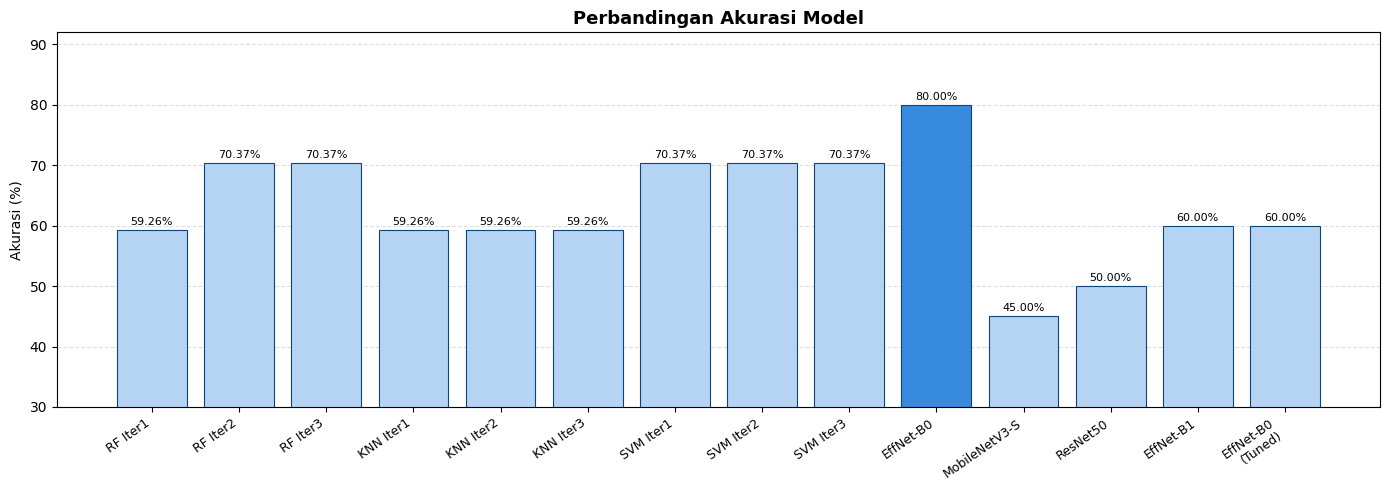

In [9]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    'RF Iter1','RF Iter2','RF Iter3',
    'KNN Iter1','KNN Iter2','KNN Iter3',
    'SVM Iter1','SVM Iter2','SVM Iter3',
    'EffNet-B0','MobileNetV3-S','ResNet50','EffNet-B1','EffNet-B0\n(Tuned)'
]
accuracy = [59.26,70.37,70.37,59.26,59.26,59.26,70.37,70.37,70.37,80.00,45.00,50.00,60.00,60.00]

colors = ['#378ADD' if v == max(accuracy) else '#B5D4F4' for v in accuracy]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(range(len(models)), accuracy, color=colors, edgecolor='#0C447C', linewidth=0.8)

for bar, val in zip(bars, accuracy):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=35, ha='right', fontsize=9)
ax.set_ylim(30, 92)
ax.set_ylabel('Akurasi (%)')
ax.set_title('Perbandingan Akurasi Model', fontsize=13, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('akurasi_model.png', dpi=150, bbox_inches='tight')
plt.show()

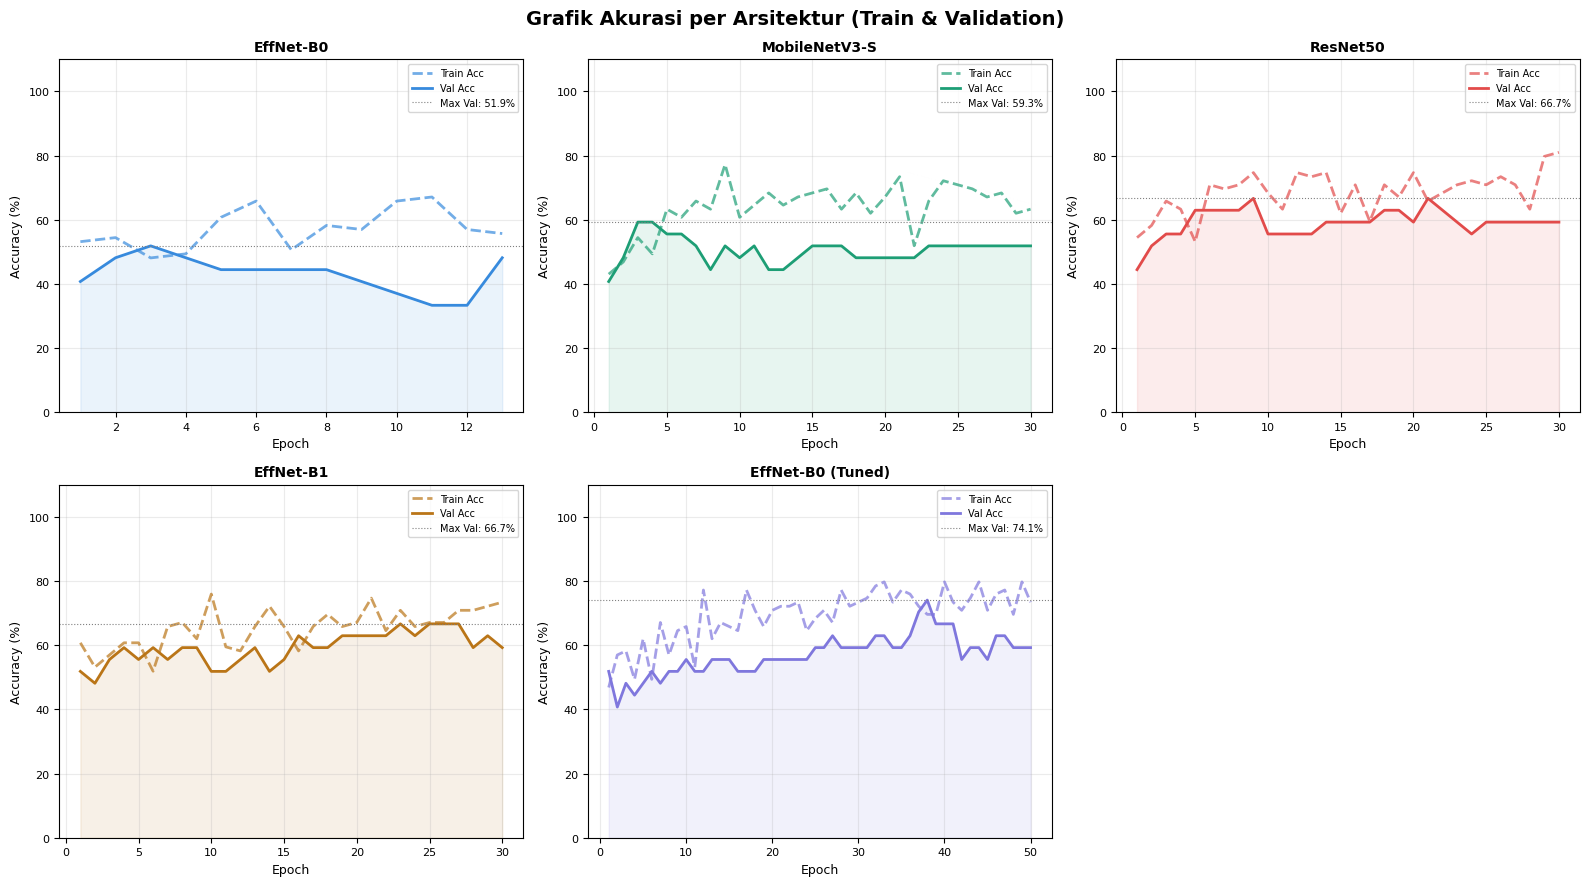

  ✓ Plot tersimpan: grafik_akurasi.png


In [ ]:
# ── Grafik Akurasi per Arsitektur (Train & Validation) ───────────────────────
fig_acc, axes_acc = plt.subplots(2, 3, figsize=(16, 9))
fig_acc.suptitle("Grafik Akurasi per Arsitektur (Train & Validation)",
                  fontsize=14, fontweight='bold')
axes_flat = axes_acc.flatten()

_palette = ['#378ADD', '#1D9E75', '#E24B4A', '#BA7517', '#7F77DD']

for i, (n, r) in enumerate(arch_results.items()):
    ax = axes_flat[i]
    h  = r['history']
    ep = range(1, len(h['val_acc']) + 1)
    c  = _palette[i % len(_palette)]
    lb = n.replace("EfficientNet", "EffNet")

    ax.plot(ep, [v*100 for v in h['train_acc']],
            color=c, linewidth=2, linestyle='--', label='Train Acc', alpha=0.7)
    ax.plot(ep, [v*100 for v in h['val_acc']],
            color=c, linewidth=2, label='Val Acc')
    ax.fill_between(ep, [v*100 for v in h['val_acc']], alpha=0.1, color=c)
    ax.axhline(max(v*100 for v in h['val_acc']),
               color='gray', linestyle=':', linewidth=0.8,
               label=f"Max Val: {max(v*100 for v in h['val_acc']):.1f}%")

    ax.set_title(lb, fontsize=10, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=9)
    ax.set_ylabel('Accuracy (%)', fontsize=9)
    ax.set_ylim(0, 110)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.25)
    ax.tick_params(labelsize=8)

# Sembunyikan subplot kosong jika model < 6
for j in range(len(arch_results), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig("grafik_akurasi.png", dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ Plot tersimpan: grafik_akurasi.png")
